<a href="https://colab.research.google.com/github/pamritha25/ML-and-DL-Projects/blob/main/HadHeart_attack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem statement**

 With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Patients Data ( Used for Heart Disease Prediction ) (4) (1).csv")

In [ ]:
df


,tientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   tientID                   237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df.duplicated().sum()

np.int64(0)

**visualization**

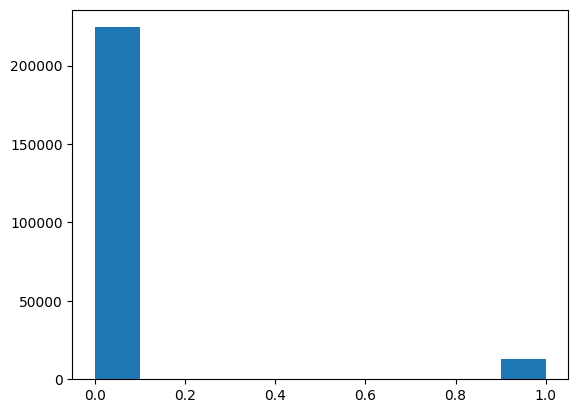

In [ ]:
plt.hist(df["HadHeartAttack"])
plt.show()

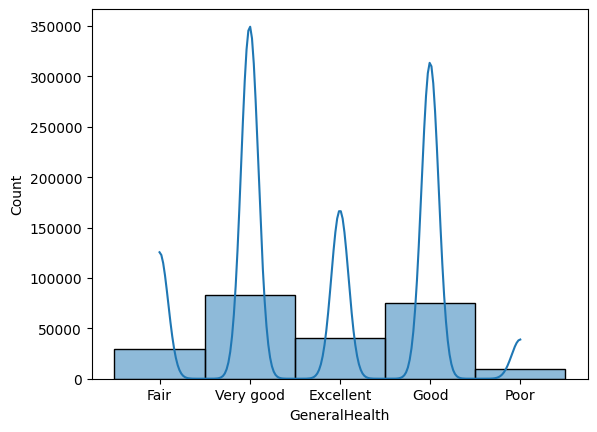

In [ ]:
sns.histplot(df["GeneralHealth"],kde=True)
plt.show()

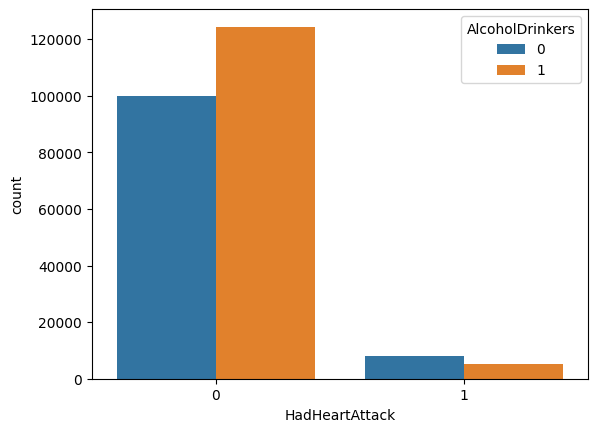

In [ ]:
sns.countplot(data=df, x='HadHeartAttack', hue='AlcoholDrinkers')
plt.show()

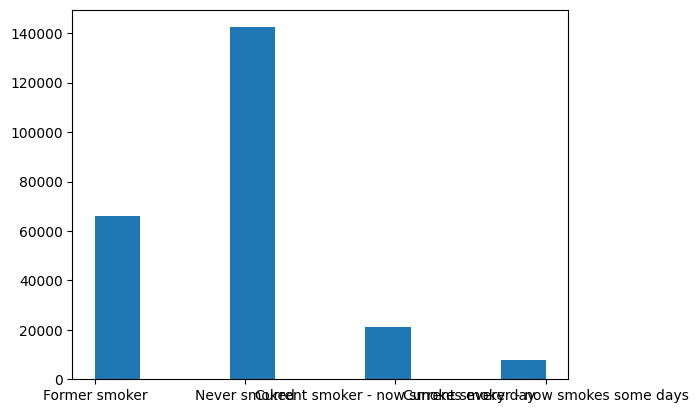

In [ ]:
plt.hist(df["SmokerStatus"])
plt.show()


In [ ]:
print(df[ 'TetanusLast10Tdap'].unique())

['No, did not receive any tetanus shot in the past 10 years'
 'Yes, received Tdap' 'Yes, received tetanus shot but not sure what type'
 'Yes, received tetanus shot, but not Tdap']


In [ ]:
print(df['RaceEthnicityCategory'].unique())

['White only, Non-Hispanic' 'Black only, Non-Hispanic'
 'Other race only, Non-Hispanic' 'Multiracial, Non-Hispanic' 'Hispanic']


In [ ]:
print(df['ECigaretteUsage'].unique())#ordinal

['Never used e-cigarettes in my entire life' 'Not at all (right now)'
 'Use them some days' 'Use them every day']


In [ ]:
df["ECigaretteUsage"].replace(["Never used e-cigarettes in my entire life",
"Not at all (right now)",
"Use them some days",
"Use them every day"],[0,1,2,3],inplace=True)


/tmp/ipython-input-1332334844.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ECigaretteUsage"].replace(["Never used e-cigarettes in my entire life",
/tmp/ipython-input-1332334844.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["ECigaretteUsage"].replace(["Never used e-cigarettes in m

In [ ]:
print(df['SmokerStatus'].unique())#ordinal

['Former smoker' 'Never smoked' 'Current smoker - now smokes every day'
 'Current smoker - now smokes some days']


In [ ]:
df["SmokerStatus"].replace(["Never smoked",
"Former smoker",
"Current smoker - now smokes some days",
"Current smoker - now smokes every day"],[0,1,2,3],inplace=True)


/tmp/ipython-input-1227496810.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["SmokerStatus"].replace(["Never smoked",
/tmp/ipython-input-1227496810.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["SmokerStatus"].replace(["Never smoked",


In [ ]:
print(df['HadDiabetes'].unique())

['Yes' 'No' 'No, pre-diabetes or borderline diabetes'
 'Yes, but only during pregnancy (female)']


In [ ]:
print(df['AgeCategory'].unique())#taking average of this

['Age 75 to 79' 'Age 65 to 69' 'Age 60 to 64' 'Age 70 to 74'
 'Age 50 to 54' 'Age 80 or older' 'Age 55 to 59' 'Age 25 to 29'
 'Age 40 to 44' 'Age 30 to 34' 'Age 35 to 39' 'Age 18 to 24'
 'Age 45 to 49']


In [ ]:
df["AgeCategory"].replace(['Age 75 to 79',"Age 65 to 69","Age 60 to 64","Age 70 to 74","Age 50 to 54","Age 80 or older","Age 55 to 59","Age 25 to 29","Age 40 to 44","Age 30 to 34","Age 35 to 39","Age 18 to 24","Age 45 to 49"],[77,67,62,72,52,85,57,27,42,32,37,21,47],inplace=True)





/tmp/ipython-input-4073214267.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["AgeCategory"].replace(['Age 75 to 79',"Age 65 to 69","Age 60 to 64","Age 70 to 74","Age 50 to 54","Age 80 or older","Age 55 to 59","Age 25 to 29","Age 40 to 44","Age 30 to 34","Age 35 to 39","Age 18 to 24","Age 45 to 49"],[77,67,62,72,52,85,57,27,42,32,37,21,47],inplace=True)
/tmp/ipython-input-4073214267.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, e

In [ ]:
print(df['GeneralHealth'].unique())

['Fair' 'Very good' 'Excellent' 'Good' 'Poor']


In [ ]:
df["GeneralHealth"].replace(["Poor",
"Fair",
"Good",
"Very good",
"Excellent"],[0,1,2,3,4],inplace=True)


/tmp/ipython-input-2397154004.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["GeneralHealth"].replace(["Poor",
/tmp/ipython-input-2397154004.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["GeneralHealth"].replace(["Poor",


In [ ]:
print(df['Sex'].unique())

['Female' 'Male']


In [ ]:
print(df['State'].unique())

['Alabama' 'Alaska' 'Arizona' 'California' 'Arkansas' 'Connecticut'
 'Colorado' 'Delaware' 'Florida' 'Georgia' 'Hawaii' 'Idaho' 'Indiana'
 'District of Columbia' 'Kansas' 'Iowa' 'Maryland' 'Minnesota' 'Montana'
 'New Jersey' 'Nebraska' 'New York' 'Ohio' 'Oklahoma' 'Texas' 'Vermont'
 'Washington' 'Utah' 'Illinois' 'West Virginia' 'Virginia' 'Massachusetts'
 'Kentucky' 'Louisiana' 'Maine' 'Wisconsin' 'Michigan' 'Mississippi'
 'Missouri' 'Nevada' 'New Hampshire' 'New Mexico' 'South Carolina'
 'North Carolina' 'North Dakota' 'Oregon' 'Pennsylvania' 'Rhode Island'
 'South Dakota' 'Tennessee' 'Wyoming' 'Guam' 'Puerto Rico'
 'Virgin Islands']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['State'] = le.fit_transform(df['State'])
df['HadDiabetes']=le.fit_transform(df['HadDiabetes'])
df['TetanusLast10Tdap']=le.fit_transform(df['TetanusLast10Tdap'])
df['RaceEthnicityCategory']=le.fit_transform(df['RaceEthnicityCategory'])
df['Sex']=le.fit_transform(df['Sex'])


In [ ]:
df

,tientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,0,0,1,77,1.63,84.820000,32.099998,0,1,...,0,1,4,0,0,0,1,0,0,1
1,2,0,0,3,67,1.60,71.669998,27.990000,0,0,...,0,0,4,0,0,1,1,1,0,0
2,3,0,1,4,62,1.78,71.209999,22.530001,0,0,...,0,0,4,1,0,0,0,2,0,0
3,4,0,1,3,72,1.78,95.250000,30.129999,0,0,...,0,0,4,0,0,1,1,2,0,0
4,5,0,0,2,52,1.68,78.019997,27.760000,0,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,40,0,2,62,1.57,90.720001,36.580002,0,0,...,1,0,1,0,0,1,0,0,0,0
237626,237627,40,0,2,57,1.70,72.570000,25.059999,0,1,...,1,0,1,0,1,0,0,1,0,0
237627,237628,40,1,1,47,1.75,70.309998,22.889999,1,1,...,1,1,1,0,1,1,1,1,1,0
237628,237629,40,0,3,27,1.57,46.720001,18.840000,0,0,...,0,0,1,0,1,0,0,0,0,1


In [ ]:
from imblearn.over_sampling import SMOTE

# Split features and target
X = df.drop("HadHeartAttack", axis=1)
y = df["HadHeartAttack"]

# Apply SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

In [ ]:
import pandas as pd

# Combine X_smote and y_smote into one DataFrame
df_cleaned = pd.concat(
    [pd.DataFrame(X_smote, columns=X.columns),
     pd.Series(y_smote, name="HadHeartAttack")],
    axis=1
)
df=df_cleaned

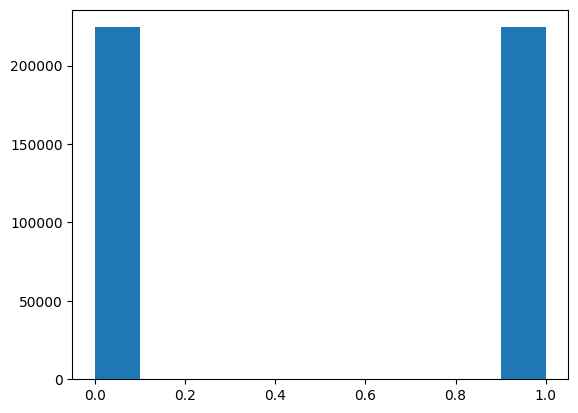

In [ ]:
plt.hist(df["HadHeartAttack"])
plt.show()

**correlation  matrix**

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


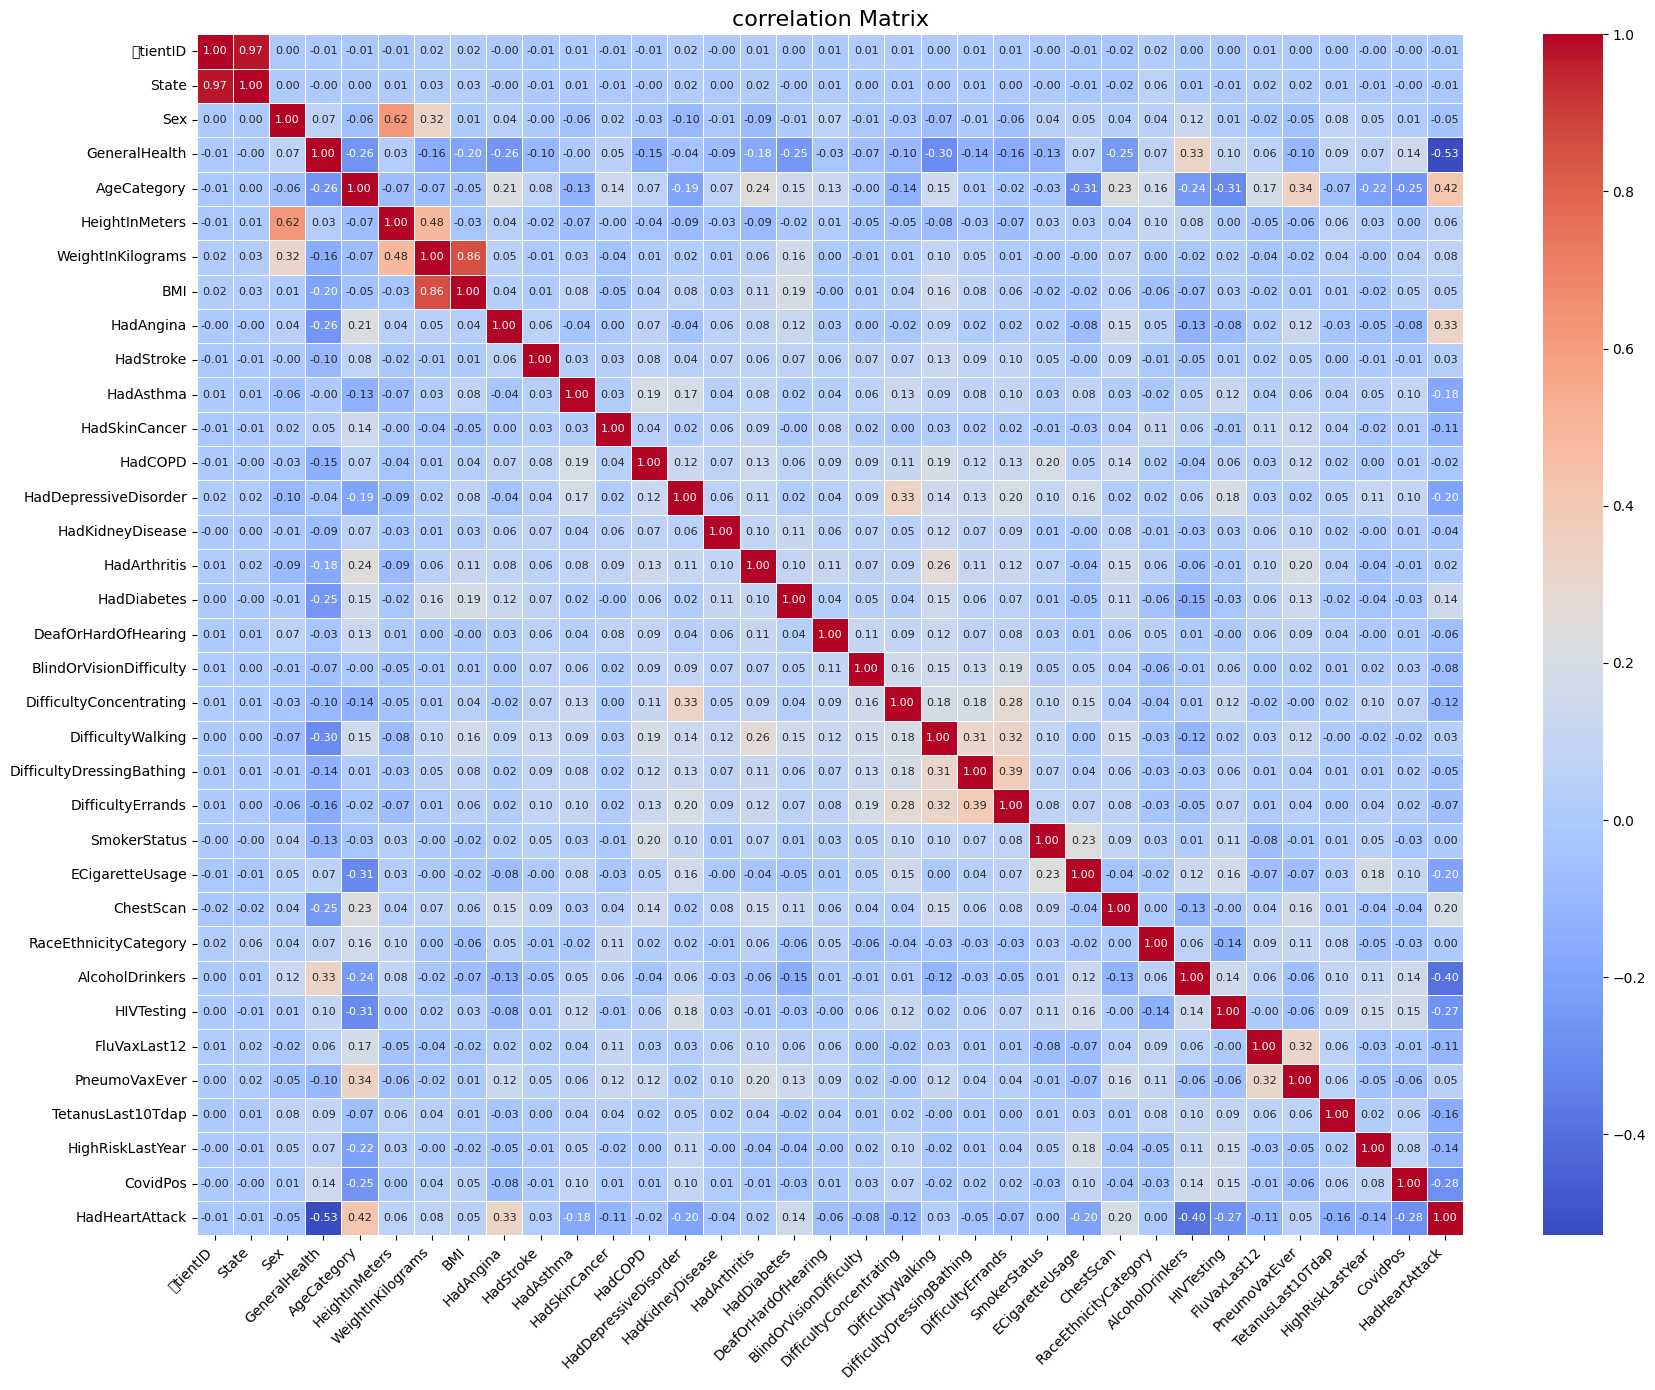

In [ ]:
plt.figure(figsize=(18,14))
corr_matrix=df.corr(numeric_only=True)
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5,annot_kws={"size":8})
plt.title("correlation Matrix",fontsize=16)
plt.xticks(rotation=45,ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df.drop(["WeightInKilograms"],axis=1,inplace=True)

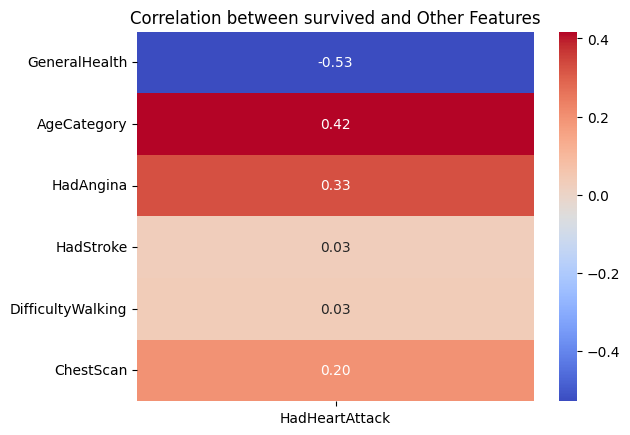

In [ ]:

survived_corr = df.corr()['HadHeartAttack']


survived_corr = survived_corr.drop('HadHeartAttack')


sns.heatmap(survived_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between survived and Other Features')
plt.show()

In [ ]:
df.drop(["tientID","State","Sex","HeightInMeters","BMI","HadAsthma","HadSkinCancer","HadDepressiveDisorder","BlindOrVisionDifficulty","DifficultyConcentrating","DifficultyDressingBathing","DifficultyErrands","SmokerStatus","ECigaretteUsage","RaceEthnicityCategory","AlcoholDrinkers","HIVTesting","FluVaxLast12","TetanusLast10Tdap","HighRiskLastYear","CovidPos"],axis=1,inplace=True)

In [ ]:
df.drop(["DeafOrHardOfHearing","HadKidneyDisease","HadArthritis","PneumoVaxEver","HadCOPD","HadDiabetes"], axis=1, inplace=True, errors='ignore')

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler



features = ["GeneralHealth","AgeCategory","HadAngina","HadStroke","DifficultyWalking","ChestScan"]

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd


X = df[["GeneralHealth","AgeCategory","HadAngina","HadStroke","DifficultyWalking","ChestScan"]]
y = df[["HadHeartAttack"]]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


model = LogisticRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Baseline model accuracy: 0.80


In [ ]:
X_test

,GeneralHealth,AgeCategory,HadAngina,HadStroke,DifficultyWalking,ChestScan
223892,2,77,0,0,1,1
392530,1,79,0,0,0,0
306046,0,73,1,0,1,1
252361,1,65,0,0,0,0
164662,2,37,0,0,0,0
...,...,...,...,...,...,...
98303,2,57,0,0,0,0
431479,2,75,0,0,1,0
298346,1,69,1,0,0,0
65763,4,42,0,0,0,0


In [ ]:
y_test

,HadHeartAttack
223892,0
392530,1
306046,1
252361,1
164662,0
...,...
98303,0
431479,1
298346,1
65763,0


In [ ]:
df

,GeneralHealth,AgeCategory,HadAngina,HadStroke,DifficultyWalking,ChestScan,HadHeartAttack
0,1,77,1,0,1,1,0
1,3,67,0,0,0,0,0
2,4,62,0,0,0,0,0
3,3,72,0,0,0,0,0
4,2,52,0,0,0,1,0
...,...,...,...,...,...,...,...
448853,1,62,0,0,0,1,1
448854,0,62,1,0,0,0,1
448855,1,66,0,0,0,1,1
448856,1,56,1,1,0,1,1


In [ ]:
df.head(50)

,GeneralHealth,AgeCategory,HadAngina,HadStroke,DifficultyWalking,ChestScan,HadHeartAttack
0,1,77,1,0,1,1,0
1,3,67,0,0,0,0,0
2,4,62,0,0,0,0,0
3,3,72,0,0,0,0,0
4,2,52,0,0,0,1,0
5,3,77,0,0,1,1,0
6,2,72,0,0,0,1,0
7,1,62,0,0,1,0,0
8,1,85,0,0,1,0,0
9,2,85,0,0,0,0,0


In [ ]:
model.predict([[2,85, 0, 0, 0, 0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.88


In [ ]:
from sklearn.svm import SVC

svclassifier = SVC(
    kernel="linear",
    cache_size=2000,
    max_iter=5000,
    random_state=42
)

svclassifier.fit(X_train, y_train)
svclassifier.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


0.540685291627679

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model =RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Baseline model accuracy: 0.88


In [ ]:
from sklearn.model_selection import KFold
kf=KFold(n_splits=8,shuffle=True,random_state=42)
model=LogisticRegression()


In [ ]:
best_accuracy = 0
best_fold = -1
best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_fold = fold
        best_X_train = X_train
        best_y_train = y_train
        best_X_test = X_test
        best_y_test = y_test
        best_y_pred = y_pred
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fold 1 Accuracy: 0.8007414272474513


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fold 2 Accuracy: 0.8029870963142511


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


...

Fold 6 Accuracy: 0.8062273869570642


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fold 7 Accuracy: 0.8018250842140909


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fold 8 Accuracy: 0.8058887482845277

 Best Fold: 6 with Accuracy: 0.8062273869570642


In [ ]:
model = LogisticRegression()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.8062273869570642

In [ ]:
model=DecisionTreeClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

NameError: name 'DecisionTreeClassifier' is not defined

In [ ]:
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.885575774858752

**dl**

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Re-define X and y from the preprocessed df to ensure correct feature count
X_dl = df.drop("HadHeartAttack", axis=1)
y_dl = df["HadHeartAttack"]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_dl)
best_X_train,best_X_test,best_y_train,best_y_test=train_test_split(X_scaled,y_dl,test_size=0.3,random_state=42)

In [ ]:
model=Sequential()
model.add(Dense(256,input_shape=(6,),activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(best_X_train.astype('float32'), best_y_train.values.ravel().astype('float32'), epochs=100, batch_size=32)

Epoch 1/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.8713 - loss: 0.2898
Epoch 2/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.8719 - loss: 0.2890
Epoch 3/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.8717 - loss: 0.2880
Epoch 4/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8711 - loss: 0.2899
Epoch 5/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.8713 - loss: 0.2876
Epoch 6/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.8710 - loss: 0.2881
Epoch 7/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8724 - loss: 0.2877
Epoch 8/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8715 - loss: 0.2876
Epoch 9/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8728 - loss: 0.2844
Epoch 10/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.8724 - loss: 0.2853
Epoch 11/100
9819/9819 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.8720 - loss: 0.2852
Epoch 12

In [ ]:
loss,accuracy=model.evaluate(best_X_test,best_y_test)
print(f'model accuracy:{accuracy*100:.2f}%')

4209/4209 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8778 - loss: 0.2705
model accuracy:87.81%


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.88


In [ ]:
import pickle
with open("heartTree model.pkl","wb") as file:
  pickle.dump(model,file)

In [ ]:
with open("/content/heartTree model.pkl","rb") as file:
  load_model=pickle.load(file)

# **Conclusion**

This project focused on predicting whether a patient has experienced a heart attack using demographic, medical, and lifestyle features. The problem was treated as a binary classification task with HadHeartAttack as the target variable. After data cleaning and preprocessing, multiple models were tested, and the Decision Tree Classifier achieved the highest accuracy of 88%. The model was then saved in pickle format for future deployment and reuse. Overall, the results show that machine learning can effectively assist in early heart attack risk prediction and support preventive healthcare decisions.

The developed model demonstrates that structured healthcare data can be transformed into meaningful insights through analytical techniques. Its performance indicates the potential for identifying high-risk individuals at an early stage. With further optimization and validation, the model can be integrated into clinical decision support systems. This project highlights the growing importance of data-driven approaches in enhancing preventive healthcare and improving patient outcomes.